# Monthly Workforce Roster — Mixed-Integer Programming

**Objective:** build a legal, fair roster for a 24/7 restaurant for one month (January 2027), and find **how many agents** the current demand really needs.

**Approach:** the model minimizes **penalties**, not wages. Missing demand is by far the most expensive penalty; surplus staff only carries a tiny penalty to keep the solution stable. Pay is calculated afterwards and reported, but not optimized.

All constants, demand data, the optimization model and the charts live in [`roster_engine.py`](roster_engine.py). This notebook only runs it and shows the results.

## Shift Codes

| Shift | Time | Break (1 hour) | Codes |
|---|---|---|---|
| **M** (Morning) | 07:00–16:00 | starts 10:00, 11:00 or 12:00 | M10, M11, M12 |
| **E** (Evening) | 14:00–23:00 | starts 17:00, 18:00 or 19:00 | E17, E18, E19 |
| **N** (Night) | 21:00–06:00 | starts 00:00, 01:00 or 02:00 | N00, N01, N02 |

Every shift is 9 hours including the break, so **8 working hours**. **Overtime** of **1 or 2 hours** (company cap) is added **B**efore or **A**fter the shift:

| Code | Meaning | Working time |
|---|---|---|
| `M10` | morning, break 10:00 | 07:00–16:00 |
| `M10_B1` | morning, break 10:00, 1h overtime **before** | 06:00–16:00 |
| `E18_A2` | evening, break 18:00, 2h overtime **after** | 14:00–01:00 |

3 shifts × 3 break hours × 5 overtime variants (none, B1, B2, A1, A2) = **45 shift codes**.

Every decision variable carries the full decision in its name, **agent_date_code**:

> `Agent01_20270101_M10_B1 = 1` → Agent01 works a morning shift with a 10:00 break and 1 hour of overtime before, on 1 January 2027.

An operating day runs **06:00 → 06:00**, so a night shift belongs to the day it starts. No base shift covers **06:00–07:00**; that hour can only be staffed with overtime (`M.._B1/B2` or `N.._A1/A2`).

## Rules

### Hard rules (never broken)

| Rule | Value | Basis |
|---|---|---|
| Regular working time | 8 h/day, max **5 work days in any 7 days** (40 h/week) | UU 13/2003 Art. 77 |
| Weekly rest | follows from the 5-in-7 rule: 2 rest days in every 7 | UU 13/2003 Art. 79 |
| Overtime limit | legal max 4 h/day and **18 h in any 7 days**; company cap **2 h per shift** | PP 35/2021 Art. 26 |
| Overtime pay | 1.5× the hourly wage for the 1st hour, 2× after | PP 35/2021 Art. 31 |
| Consecutive work days | max **5** in a row | Company policy |
| Consecutive days off | max **2** in a row | Company policy |
| Work between leave | no **DO–Work–DO** (no single work day between days off) | Company policy |
| Overtime | never on **two consecutive days** | Company policy |
| Rotation | no **night → morning**: a shift ending after midnight (incl. overtime) is never followed by M | Company policy |
| Rest between shifts | at least **8 hours** | Company policy |
| Weekend | every agent is off on **at least one** of Saturday / Sunday | Company policy |

The month is one continuous sequence: a pattern at the end of one week carries into the next. For example, after `Work–DO–DO–Work–Work–Work–Work–Work` the next day **must** be a day off.

### Soft rules (penalties, minimized)

| Penalty | Weight | Per |
|---|---|---|
| Under-demand | **1,000** | missing agent-hour |
| Agents | 10,000 | agent (stage 1 only, after under-demand is minimized) |
| Overtime | 20 | overtime hour |
| Overtime balance | 10 | hour of the highest individual overtime total |
| Shift balance (M / E / N) | 5 | shift an agent is away from the team average, for each of M, E, N |
| Over-demand | 1 | surplus agent-hour (only to stabilize the solution) |

Labor-law values follow UU 13/2003 as amended by UU 6/2023 and PP 35/2021; check the current regulation before operational use.

## Mathematical Formulation

One model deciding head count, days off and every shift for every person over a month is too large for the open-source CBC solver (a first attempt found no valid roster in 10 minutes). It is solved as **three stages**, each small enough to solve well.

### Sets and indices

| Symbol | Meaning |
|---|---|
| $a \in \mathcal{A}$ | agents (Agent01, Agent02, …) |
| $d \in \mathcal{D} = \{1, \dots, 31\}$ | operating days of January 2027 |
| $t \in \mathcal{T} = \{1, \dots, 744\}$ | hours of the month |
| $s \in \mathcal{S} = \{M, E, N\}$ | base shifts |
| $c \in \mathcal{C}$ | the 45 shift codes; $\mathcal{C}_s$ = codes of shift $s$; $\mathcal{C}^{OT}$ = codes with overtime |
| $\mathcal{C}^{night} \subset \mathcal{C}$ | codes that end after midnight (all N, and E with overtime after) |
| $\mathcal{K}(c) \subset \mathcal{C}$ | codes that may **not** follow $c$ the next day (rest < 8 h, or night → morning) |
| $\mathcal{W} \subset \mathcal{D}$ | Saturdays whose Sunday is also in the month |

### Parameters

| Symbol | Meaning |
|---|---|
| $r_t$ | agents required in hour $t$ (from customers per hour) |
| $\alpha_{c,d,t} \in \{0,1\}$ | 1 if code $c$ worked on day $d$ is **on duty** in hour $t$ (break excluded) |
| $h_c \in \{0,1,2\}$ | overtime hours of code $c$ |
| $\bar{w} = 5,\ \bar{q} = 5,\ \bar{o} = 2,\ \bar{H} = 18$ | max work days in any 7, max consecutive work days, max consecutive days off, max overtime hours in any 7 days |

### Stage 1 — staffing plan: head count, and agents per code per day

Choosing the break separately from shift + overtime is equivalent (any break hour can go with any overtime) but much smaller to solve. Let $\tau \in \mathcal{G}$ be the 15 shift + overtime combinations (M, M_B1, M_B2, M_A1, M_A2, E, …), $\mathcal{G}_s$ those of shift $s$, $\beta \in \mathcal{B}_s$ the break hours of shift $s$, and $\gamma_{\tau,d,t} \in \{0,1\}$ = 1 if $\tau$ on day $d$ spans hour $t$ (break included).

Variables: $n_{d,\tau} \in \mathbb{Z}_{\ge 0}$ (named e.g. `n_20270101_M_B1`), break counts $b_{d,s,\beta} \in \mathbb{Z}_{\ge 0}$ (e.g. `break_20270101_M10`), head count $P \in \mathbb{Z}_{\ge 0}$, shortage $u_t \ge 0$, surplus $v_t \ge 0$.

$$\sum_{\beta \in \mathcal{B}_s} b_{d,s,\beta} = \sum_{\tau \in \mathcal{G}_s} n_{d,\tau} \qquad \forall d, s \qquad \text{(every agent on shift } s \text{ takes one break)}$$

$$\sum_{d}\sum_{\tau} \gamma_{\tau,d,t}\, n_{d,\tau} - \sum_{d,s,\beta:\ \beta \text{ falls in hour } t} b_{d,s,\beta} + u_t - v_t = r_t \qquad \forall t \in \mathcal{T} \qquad \text{(hourly coverage)}$$

Per-agent rules, in aggregate over the team ($\forall d$ where the window fits in the month):

$$\sum_{\tau} n_{d,\tau} \le P \qquad \sum_{i=0}^{6}\sum_{\tau} n_{d+i,\tau} \le \bar{w}\,P \qquad \sum_{i=0}^{\bar{o}}\sum_{\tau} n_{d+i,\tau} \ge P$$

$$\sum_{\tau \in \mathcal{G}^{OT}} \left(n_{d,\tau} + n_{d+1,\tau}\right) \le P \qquad \sum_{i=0}^{6}\sum_{\tau} h_\tau\, n_{d+i,\tau} \le \bar{H}\,P$$

$$\sum_{\tau \in \mathcal{G}^{night}} n_{d,\tau} + \sum_{\tau \in \mathcal{G}_M} n_{d+1,\tau} \le P \qquad \sum_{\tau} \left(n_{d,\tau} + n_{d+1,\tau}\right) \le P \quad \forall d \in \mathcal{W}$$

Objective, solved in priority order (lexicographic):

$$\text{(i)}\;\; U^* = \min \sum_{t} u_t \qquad\qquad \text{(ii)}\;\; \min\; 10000\,P + 20 \sum_{d,\tau} h_\tau\, n_{d,\tau} + \sum_{t} v_t \quad \text{s.t. } \sum_{t} u_t \le U^*$$

The counts are then combined back into the 45 shift codes: $n^*_{d,c}$ = agents planned on code $c$ on day $d$.

### Stage 2 — day pattern: which days each agent works

Variables: $w_{a,d} \in \{0,1\}$ (named e.g. `Agent01_20270101_work`); slack $m_d, e_d \ge 0$; $D^{min}, D^{max} \ge 0$. Input: $N_d = \sum_c n^*_{d,c}$ from stage 1, with $|\mathcal{A}| = P^*$.

$$\sum_{i=0}^{6} w_{a,d+i} \le \bar{w} \qquad \sum_{i=0}^{\bar{q}} w_{a,d+i} \le \bar{q} \qquad \sum_{i=0}^{\bar{o}} w_{a,d+i} \ge 1 \qquad \forall a, d$$

$$w_{a,d} \le w_{a,d-1} + w_{a,d+1} \;\; \text{(no DO–Work–DO)} \qquad w_{a,d} + w_{a,d+1} \le 1 \;\; \forall d \in \mathcal{W} \;\; \text{(a weekend day off)}$$

$$\sum_{a} w_{a,d} + m_d - e_d = N_d \quad \forall d \qquad\qquad D^{min} \le \sum_{d} w_{a,d} \le D^{max} \quad \forall a$$

$$\min\; 1000 \cdot 8 \sum_{d} m_d + 8 \sum_{d} e_d + 5\,(D^{max} - D^{min})$$

### Stage 3 — shift codes: which code each agent works on each work day

Variables: $x_{a,d,c} \in \{0,1\}$ for every work day $(a,d)$ with $w^*_{a,d} = 1$, named e.g. **`Agent01_20270101_M10_B1`**; shortage $u_t \ge 0$; surplus $v_t \ge 0$; balance deviations $\delta_{a,s} \ge 0$; peak individual overtime $z \ge 0$.

$$\sum_{c} x_{a,d,c} = 1 \qquad \forall (a,d) : w^*_{a,d} = 1 \qquad \text{(one code per work day)}$$

$$x_{a,d,c} + \sum_{c' \in \mathcal{K}(c)} x_{a,d+1,c'} \le 1 \qquad \text{(rest, no night → morning)}$$

$$\sum_{c \in \mathcal{C}^{OT}} \left(x_{a,d,c} + x_{a,d+1,c}\right) \le 1 \qquad \sum_{i=0}^{6}\sum_{c} h_c\, x_{a,d+i,c} \le \bar{H} \qquad \text{(overtime)}$$

$$\sum_{a}\sum_{d}\sum_{c} \alpha_{c,d,t}\, x_{a,d,c} + u_t - v_t = r_t \qquad \forall t \qquad \text{(hourly coverage)}$$

$$\delta_{a,s} \ge \left| \sum_{d}\sum_{c \in \mathcal{C}_s} x_{a,d,c} - \frac{1}{|\mathcal{A}|}\sum_{a'}\sum_{d}\sum_{c \in \mathcal{C}_s} x_{a',d,c} \right| \qquad z \ge \sum_{d}\sum_{c} h_c\, x_{a,d,c} \qquad \forall a, s$$

$$\min\; 1000 \sum_{t} u_t + 20 \sum_{a,d,c} h_c\, x_{a,d,c} + 10\, z + 5 \sum_{a,s} \delta_{a,s} + \sum_{t} v_t$$

(The absolute value is linearized with two inequalities, as in the code.)

**Warm start.** Before solving, a valid roster is built greedily day by day: each working agent takes a planned code $c$ (from $n^*_{d,c}$) that is allowed after the code they worked the day before, otherwise any allowed code without overtime. The solver starts from this roster and improves it, instead of searching for a first valid one among tens of thousands of binary variables.

### Solution set

The roster is the set of stage-3 variables equal to 1:

$$X^* = \{\, (a, d, c) : x^*_{a,d,c} = 1 \,\}$$

Every agent–day pair is either in $X^*$ with exactly one code, or a day off (DO).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import roster_engine as E
from report_builder import build_executive_report

RESULT_DIR = "../result"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 40)

## STEP 01 - Demand

Customers per hour are converted into agents needed per hour with a workload standard:

$$r = \max\left(\text{min crew},\; \left\lceil \frac{\text{customers/hour} \times \text{minutes per customer}}{60 \times \text{utilization}} \right\rceil + \text{support agents}\right)$$

The demand is **identical every day**. It is an assumption, not measured data: 07:00–23:00 follows the Self-Order Terminal project's demand curve, and overnight traffic is assumed. In practice the customers-per-hour numbers would come from a **demand forecast**, the single biggest lever on how accurate the final head count is.

,06:00,07:00,08:00,09:00,10:00,11:00,12:00,13:00,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00,00:00,01:00,02:00,03:00,04:00,05:00
customers / hour,10,15,20,21,28,58,87,67,33,23,30,49,64,54,34,23,18,14,10,8,5,4,4,6
agents needed,3,4,4,4,5,7,9,7,5,4,5,6,7,6,5,4,3,3,3,3,3,3,3,3


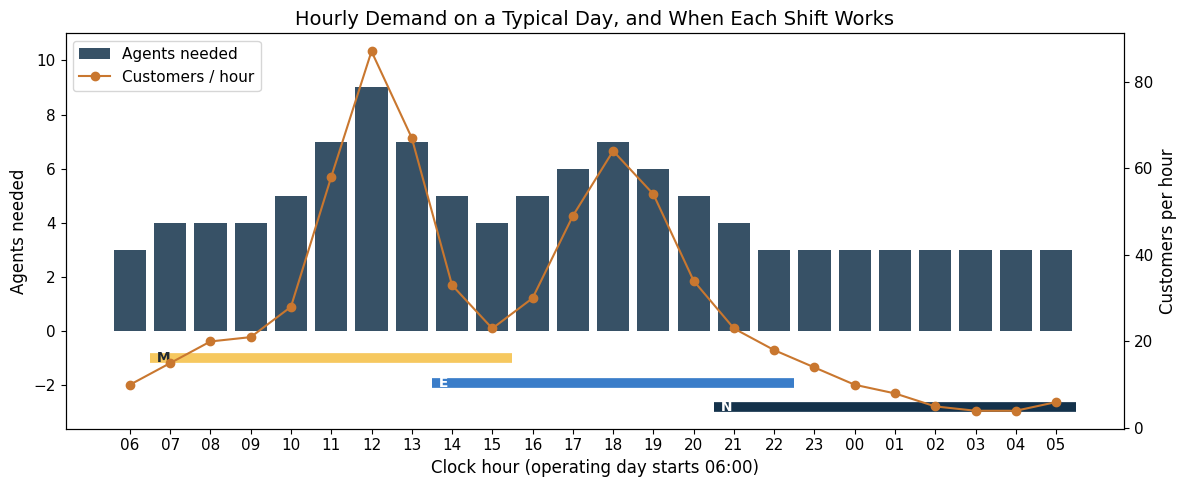

109 agent-hours per day, 3,379 for the month


In [2]:
demand = E.demand_table()
need = E.agents_needed_per_hour()
hours = [(E.DAY_START_HOUR + k) % 24 for k in range(24)]
display(pd.DataFrame({"customers / hour": [E.CUSTOMERS_PER_HOUR[h] for h in hours],
                      "agents needed": [need[h] for h in hours]},
                     index=[f"{h:02d}:00" for h in hours]).T)
E.plot_hourly_demand(os.path.join(FIG_DIR, "hourly_demand.png"))
plt.show()
print(f"{sum(need.values())} agent-hours per day, {sum(need.values()) * len(E.planning_days()):,} for the month")

## STEP 02 - Shift Codes

In [3]:
catalog = E.catalog_table()
print(f"{len(catalog)} shift codes")
catalog

45 shift codes


,code,time,break,work_hours,overtime_hours
0,M10,07:00-16:00,10:00-11:00,8,0
1,M10_B1,06:00-16:00,10:00-11:00,9,1
2,M10_B2,05:00-16:00,10:00-11:00,10,2
3,M10_A1,07:00-17:00,10:00-11:00,9,1
4,M10_A2,07:00-18:00,10:00-11:00,10,2
5,M11,07:00-16:00,11:00-12:00,8,0
6,M11_B1,06:00-16:00,11:00-12:00,9,1
7,M11_B2,05:00-16:00,11:00-12:00,10,2
8,M11_A1,07:00-17:00,11:00-12:00,9,1
9,M11_A2,07:00-18:00,11:00-12:00,10,2


## STEP 03 - Solve the Three Stages

In [4]:
plan, pattern, roster = E.build_roster(demand, time_limits=(120, 120, 600))
print(f"Stage 3 model: {len(roster.x):,} binary variables x(agent, date, code)")

Stage 1 - staffing plan: Feasible (time limit), 38 agents


Stage 2 - day pattern:   Feasible (time limit), 0 planned agent-days not staffed


Stage 3 - shift codes:   Feasible (time limit), 1 agent-hours short
Stage 3 model: 33,120 binary variables x(agent, date, code)


## STEP 04 - How Many Agents Are Needed?

In [5]:
long = E.roster_long(roster)
coverage = E.coverage_table(long, demand, roster.days)
summary = E.agent_summary(long)

AGENTS = len(roster.agent_ids)
SHORT_HOURS = int((-coverage["gap"].clip(upper=0)).sum())
SURPLUS_HOURS = int(coverage["gap"].clip(lower=0).sum())
REQUIRED_HOURS = int(coverage["required"].sum())
COVERED_PCT = 1 - SHORT_HOURS / REQUIRED_HOURS

print(f"Agents needed: {AGENTS}")
print(f"Shifts worked this month: {len(long)} ({(long['overtime_hours'] > 0).sum()} with overtime)")
print(f"Demand covered: {COVERED_PCT:.2%} of {REQUIRED_HOURS:,} required agent-hours "
      f"({SHORT_HOURS} short, {SURPLUS_HOURS:,} surplus)")
E.penalty_breakdown(plan, pattern, roster).style.format({"amount": "{:,.1f}"})

Agents needed: 38
Shifts worked this month: 736 (203 with overtime)
Demand covered: 99.97% of 3,379 required agent-hours (1 short, 2,823 surplus)


,stage,term,amount
0,1 Staffing plan,under_demand,0.0
1,1 Staffing plan,agents,38.0
2,1 Staffing plan,overtime,313.0
3,1 Staffing plan,over_demand,"2,822.0"
4,2 Day pattern,missing_agent_days,0.0
5,2 Day pattern,extra_agent_days,0.0
6,2 Day pattern,days_spread,1.0
7,3 Shift codes,under_demand,1.0
8,3 Shift codes,overtime,313.0
9,3 Shift codes,overtime_balance,14.0


### Head count vs overtime

The head count above is the **smallest** team that covers demand. More agents would mean less overtime but more idle hours; fewer agents leave demand uncovered. The table re-solves the staffing plan (stage 1) with the head count fixed at each value.

In [6]:
frontier = E.staffing_frontier(demand, [AGENTS - 2, AGENTS - 1, AGENTS, AGENTS + 2, AGENTS + 5, AGENTS + 10])
frontier

,agents,status,short_hours,overtime_hours,surplus_hours
0,36,Optimal,10,333,2772
1,37,Feasible (time limit),5,323,2797
2,38,Optimal,0,313,2822
3,40,Optimal,0,273,2862
4,43,Optimal,0,213,2922
5,48,Optimal,0,133,3042


### What drives the head count?

Each weekend needs about as many agents on Saturday as on Sunday, and the weekend-off rule forbids anyone from working both days, so the team must be at least as large as the Saturday and Sunday shifts combined. The staffing plan is re-solved without that rule to measure its cost.

In [7]:
impact = E.rule_impact(demand)
impact

,agents,shifts_per_month,short_hours,overtime_hours,surplus_hours
scenario,,,,,
All rules,38,736,0,313,2822
Without the weekend-off rule,27,599,0,737,2150


## STEP 05 - The Solution Set

The variables equal to 1 in stage 3, i.e. $X^*$. Each name reads **agent_date_code**.

In [8]:
solution_set = pd.Series(roster.chosen_variables(), name="variable = 1")
solution_set.to_csv(os.path.join(RESULT_DIR, "solution_set_january_2027.csv"), index=False)
print(f"|X*| = {len(solution_set)} assignments (full list: result/solution_set_january_2027.csv)")
solution_set.head(12).to_frame()

|X*| = 736 assignments (full list: result/solution_set_january_2027.csv)


,variable = 1
0,Agent01_20270103_M10
1,Agent01_20270104_E19
2,Agent01_20270105_N00
3,Agent01_20270107_M11
4,Agent01_20270108_E18
5,Agent01_20270110_N00
6,Agent01_20270111_E17
7,Agent01_20270113_M10
8,Agent01_20270114_M11
9,Agent01_20270115_N01


## STEP 06 - The Roster

Rows are agents, columns are dates, and each cell is that agent's shift code for the day (`DO` = day off).

In [9]:
pivot = E.roster_pivot(long, roster)
pivot.to_csv(os.path.join(RESULT_DIR, "roster_january_2027.csv"))
long.drop(columns=[c for c in long.columns if c.startswith("_")]).to_csv(
    os.path.join(RESULT_DIR, "roster_shifts_january_2027.csv"), index=False)
pivot

,2027-01-01,2027-01-02,2027-01-03,2027-01-04,2027-01-05,2027-01-06,2027-01-07,2027-01-08,2027-01-09,2027-01-10,2027-01-11,2027-01-12,2027-01-13,2027-01-14,2027-01-15,2027-01-16,2027-01-17,2027-01-18,2027-01-19,2027-01-20,2027-01-21,2027-01-22,2027-01-23,2027-01-24,2027-01-25,2027-01-26,2027-01-27,2027-01-28,2027-01-29,2027-01-30,2027-01-31
agent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Agent01,DO,DO,M10,E19,N00,DO,M11,E18,DO,N00,E17,DO,M10,M11,N01,DO,E17,N01_A1,DO,M11,E18,N00,DO,M10,E19,DO,DO,N01,E17,N02,DO
Agent02,M10,E18_B2,DO,DO,M10,E18,DO,N01,N00_B2,DO,M11,E17,DO,M11,N02,DO,N00,E17,M10,DO,E18,N01,DO,M10,E19,N01,DO,DO,M10,E17_B2,DO
Agent03,M10,DO,E17_B2,N01,E17,DO,DO,M10,M12_B1,DO,DO,N02,E17,N02_A1,N00,E17,DO,DO,M10,M11,DO,E17,N01,DO,M11,E17,N01_A1,DO,M10,E17_B2,DO
Agent04,M10,E19_B2,DO,DO,M10,E18,DO,N02,N00_B2,DO,M11_B1,E17,N00,DO,M10,E17_B2,DO,N02_A1,N00,DO,M10,E17,DO,M10,E19,DO,DO,N02,E17,M11_A2,DO
Agent05,DO,DO,M10,E19,DO,M10,N02,E17,DO,N00,E17,DO,M10,M11_B1,N02,DO,N00_A1,N00,DO,E17,M10,E17,DO,M11,N01_A1,DO,E18,M10,DO,DO,E17
Agent06,M10,DO,E17_B2,N01,DO,M10,E18,N00,DO,E17,M11,DO,DO,E17,M10,M10_B1,DO,DO,N01,N00,E17,DO,DO,N00_B2,E17,DO,M10,N02,E17,DO,M10
Agent07,DO,DO,M10,E19,N00,E17,M10,DO,DO,N01,E17,M10,M10,E17,DO,DO,N01_A1,N00,DO,M11,E18,DO,DO,N00_B2,E17,M10,M10,E17,DO,DO,N00_B2
Agent08,M10,M10_B1,DO,E19,N01,DO,E18,N00,DO,N02,E18,DO,M11,E17,DO,DO,M10_B1,M10,N02,DO,DO,E17,N02,DO,DO,M10,E18,M10,N01,E17,DO
Agent09,M10,DO,E17_B2,N02,DO,M10,E18,DO,DO,M10_B1,N00,DO,E17,N02_A1,N00,DO,M10_B1,E17,DO,DO,M11,E18,E17,DO,DO,N02,N00,E17,M10,M10_B1,DO


In [10]:
# Agents on M, E and N each day
E.daily_shift_counts(long, roster.days)

,2027-01-01,2027-01-02,2027-01-03,2027-01-04,2027-01-05,2027-01-06,2027-01-07,2027-01-08,2027-01-09,2027-01-10,2027-01-11,2027-01-12,2027-01-13,2027-01-14,2027-01-15,2027-01-16,2027-01-17,2027-01-18,2027-01-19,2027-01-20,2027-01-21,2027-01-22,2027-01-23,2027-01-24,2027-01-25,2027-01-26,2027-01-27,2027-01-28,2027-01-29,2027-01-30,2027-01-31
shift,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
M,11,7,8,11,11,11,11,11,8,8,11,11,11,11,11,9,8,10,11,11,11,11,8,8,11,11,11,11,11,8,8
E,10,8,8,10,10,10,10,10,8,7,10,10,10,10,10,7,7,10,10,10,10,10,7,8,10,10,10,10,10,7,7
N,5,4,3,5,5,5,5,5,3,4,5,5,5,5,5,3,4,6,5,5,5,5,4,3,5,5,5,5,5,4,4


In [11]:
# Which shift codes are used, over the whole month
long["code"].value_counts().rename("shifts this month").to_frame().T

code,M10,E17,E19,M11,E18,N00,E17_B2,M12_B1,N02,M12_A2,N01,M11_B1,M10_B1,E19_A2,M12,N02_A1,N01_A1,E19_B2,N00_B2,M11_A2,E18_B2,N00_A1,E17_A2,N01_B2,N02_B2,E18_A2
shifts this month,130,80,77,64,59,55,38,35,28,26,25,18,16,15,15,12,10,9,8,6,3,2,2,1,1,1


## STEP 07 - Coverage

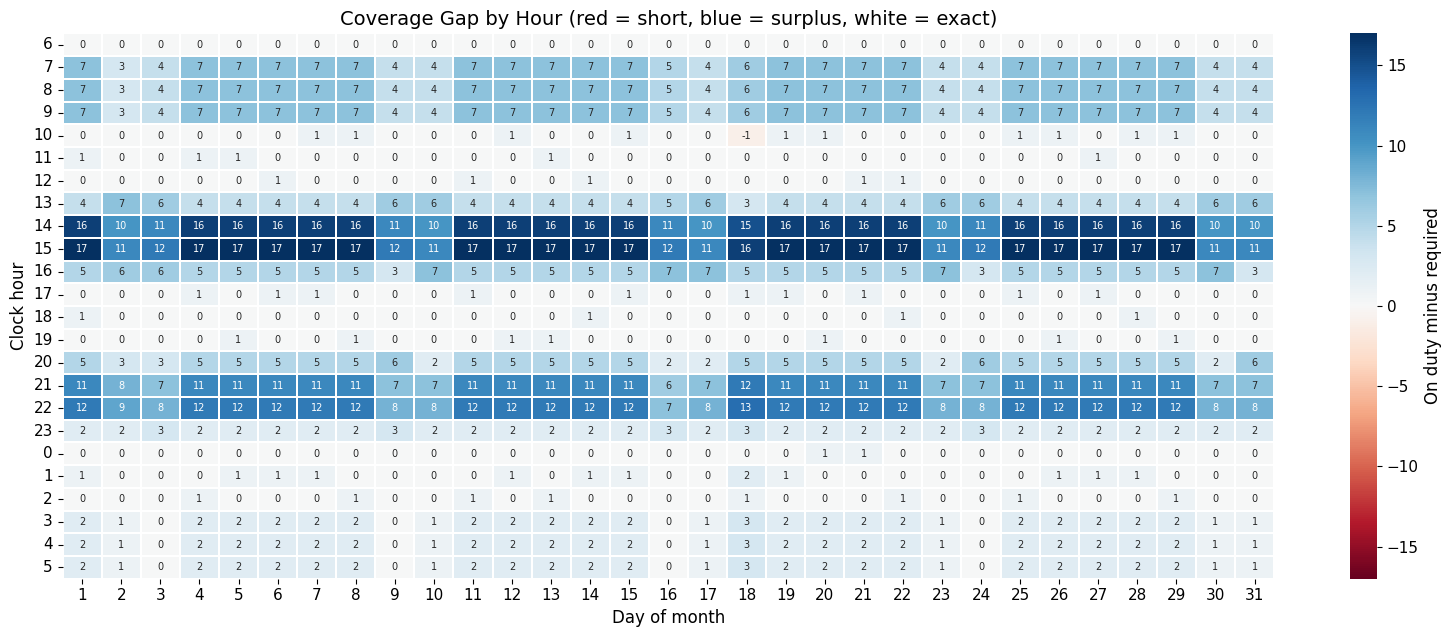

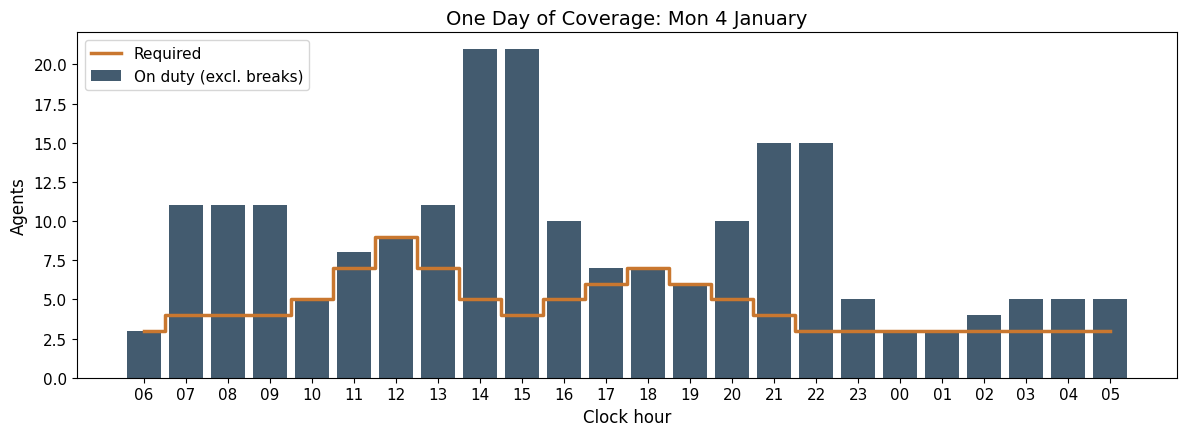

,06:00,07:00,08:00,09:00,10:00,11:00,12:00,13:00,14:00,15:00,16:00,17:00,18:00,19:00,20:00,21:00,22:00,23:00,00:00,01:00,02:00,03:00,04:00,05:00
mean,0.0,6.0,6.0,6.0,0.3,0.2,0.2,4.6,14.2,15.2,5.2,0.3,0.1,0.2,4.5,9.7,10.7,2.2,0.1,0.4,0.3,1.6,1.6,1.6
min,0.0,3.0,3.0,3.0,-1.0,0.0,0.0,3.0,10.0,11.0,3.0,0.0,0.0,0.0,2.0,6.0,7.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,7.0,7.0,7.0,1.0,1.0,1.0,7.0,16.0,17.0,7.0,1.0,1.0,1.0,6.0,12.0,13.0,3.0,1.0,2.0,1.0,3.0,3.0,3.0


In [12]:
E.plot_coverage_heatmap(coverage, roster.days, os.path.join(FIG_DIR, "coverage_heatmap.png"))
plt.show()
E.plot_day_coverage(coverage, 3, os.path.join(FIG_DIR, "day_coverage.png"))
plt.show()

by_hour = coverage.groupby("clock_hour")["gap"].agg(["mean", "min", "max"]).reindex(hours)
by_hour.index = [f"{h:02d}:00" for h in hours]
by_hour.round(1).T

## STEP 08 - Fairness: Shift Mix and Overtime per Agent

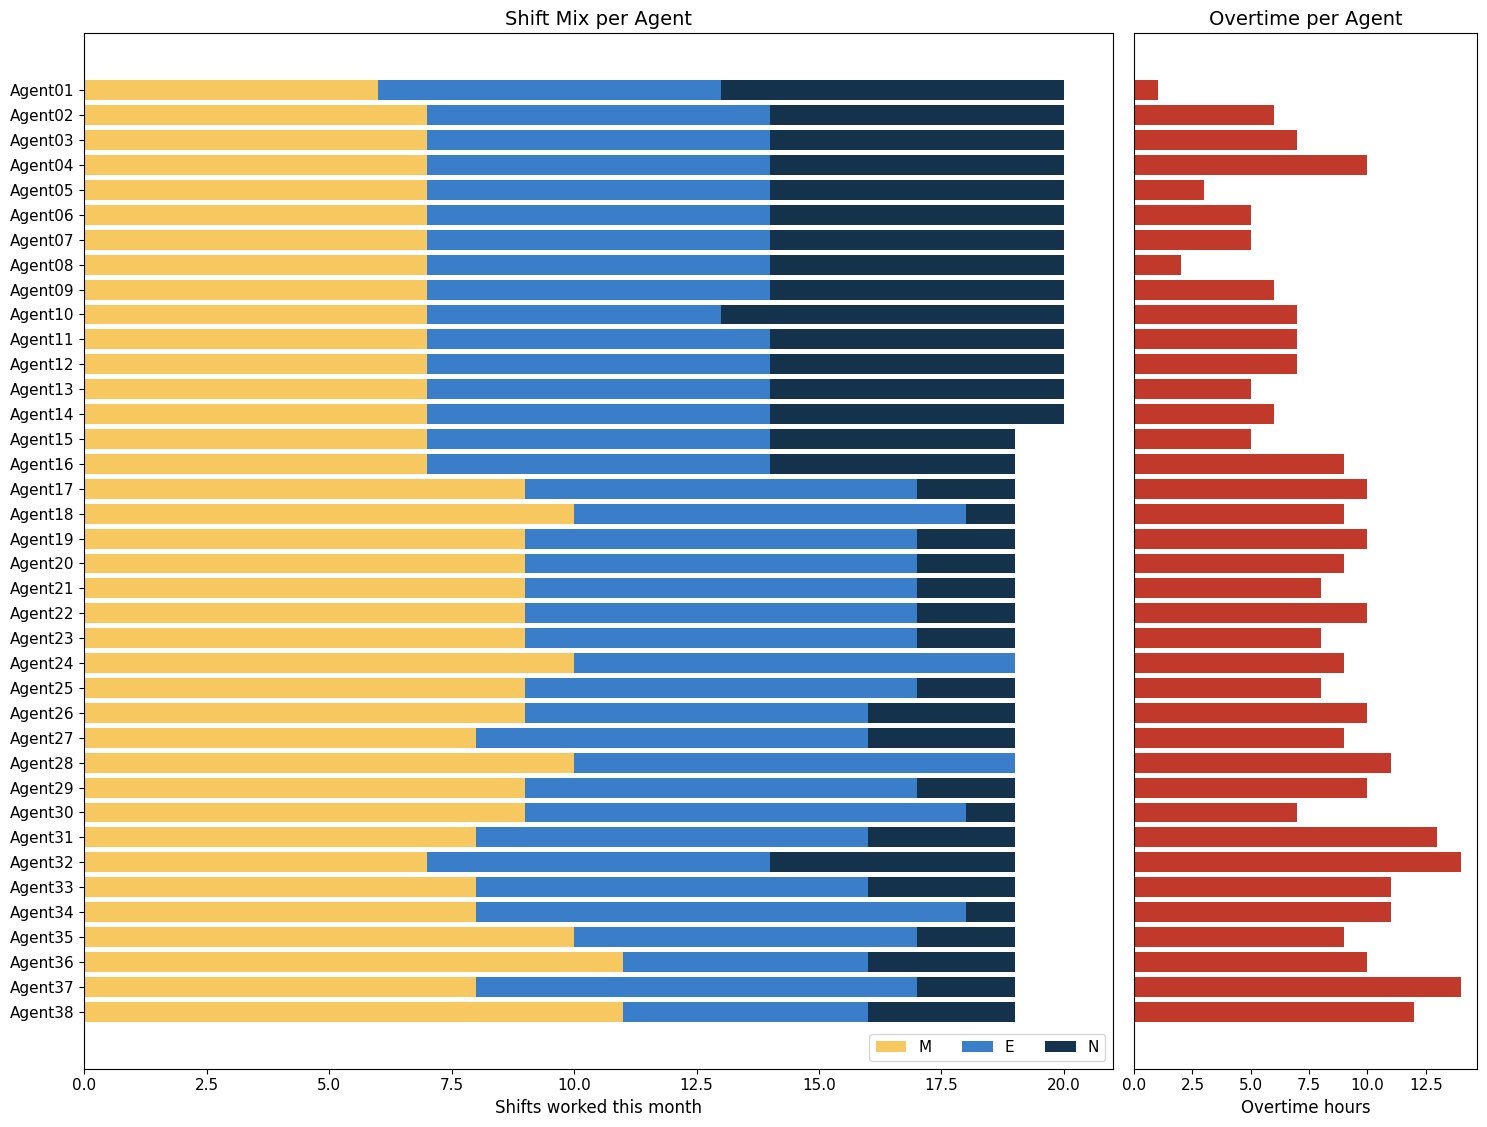

,days,work_hours,overtime_hours,pay,M,E,N
agent_id,,,,,,,
Agent01,20,161,1,"Rp 5,006,500",6,7,7
Agent02,20,166,6,"Rp 5,285,500",7,7,6
Agent03,20,167,7,"Rp 5,316,500",7,7,6
Agent04,20,170,10,"Rp 5,487,000",7,7,6
Agent05,20,163,3,"Rp 5,099,500",7,7,6
Agent06,20,165,5,"Rp 5,223,500",7,7,6
Agent07,20,165,5,"Rp 5,223,500",7,7,6
Agent08,20,162,2,"Rp 5,053,000",7,7,6
Agent09,20,166,6,"Rp 5,254,500",7,7,6


In [13]:
E.plot_agent_balance(summary, os.path.join(FIG_DIR, "agent_balance.png"))
plt.show()
summary.style.format({"pay": "Rp {:,.0f}"})

## STEP 09 - Compliance Check

Every hard rule re-checked directly from the finished roster, independently of the solver.

In [14]:
compliance = E.compliance_checks(long, roster)
compliance

,Hard rule,Result,Limit,OK
0,Max work days in any 7 days,5,5,True
1,Longest run of work days,5,5,True
2,Longest run of days off,2,2,True
3,Max overtime hours in one shift,2,2,True
4,Max overtime hours in any 7 days,5,18,True
5,Overtime on two consecutive days,0,0,True
6,DO-Work-DO patterns,0,0,True
7,Agents working both Sat and Sun,0,0,True
8,Night -> morning rotations,0,0,True
9,Rest under 8h between shifts,0,0,True


## STEP 10 - Pay (reported, not optimized)

In [15]:
regular_pay = (E.HOURLY_WAGE * (long["work_hours"] - long["overtime_hours"])).sum()
overtime_pay = long["pay"].sum() - regular_pay
MONTHLY_PAY = long["pay"].sum()
pd.DataFrame({"Rupiah": [regular_pay, overtime_pay, MONTHLY_PAY]},
             index=["Regular pay", "Overtime pay", "Total"]).style.format("Rp {:,.0f}")

,Rupiah
Regular pay,"Rp 182,528,000"
Overtime pay,"Rp 16,259,500"
Total,"Rp 198,787,500"


## STEP 11 - Executive Report

In [16]:
# Roster picture for the slides only (the notebook shows the roster as the pivot table above)
E.plot_roster(long, roster, os.path.join(FIG_DIR, "roster.png"))
plt.close("all")

report_path = build_executive_report(
    results=dict(agents=AGENTS, shifts=len(long), ot_shifts=int((long["overtime_hours"] > 0).sum()),
                 covered_pct=COVERED_PCT, short_hours=SHORT_HOURS, surplus_hours=SURPLUS_HOURS,
                 required_hours=REQUIRED_HOURS, monthly_pay=MONTHLY_PAY, overtime_pay=overtime_pay,
                 compliance=compliance, summary=summary, frontier=frontier, impact=impact,
                 surplus_by_hour=coverage.groupby("clock_hour")["gap"].mean().clip(lower=0)),
    figures={name: os.path.join(FIG_DIR, f"{name}.png")
             for name in ["hourly_demand", "roster", "coverage_heatmap", "agent_balance"]},
    output_dir=RESULT_DIR,
)
print(f"Report saved to {report_path}")

Report saved to ../result\slides\Executive_Workforce_Roster_Report_20261005.pptx
